# 01 - Exploración inicial del dataset Cora

En este notebook vamos a cargar el conjunto de datos Cora, analizar su estructura básica y construir el grafo de citaciones usando NetworkX.

Los objetivos iniciales son:

- Leer los archivos `cora.content` y `cora.cites`.
- Contar el número de nodos.
- Contar el número de aristas.
- Ver las clases disponibles.
- Construir el grafo con NetworkX.

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
contenido = pd.read_csv("../data/raw/cora.content", sep="\t", header=None)
contenido.head()
# la columna 0 se corresponde al id del nodo, las columnas 1 a 1433 corresponden al los atriibutos 
# de palabra y la columna 1434 se corresponde a la clase a la que pertenece cada nodo

,0,1,2,3,4,5,6,7,8,9,...,1425,1426,1427,1428,1429,1430,1431,1432,1433,1434
0,31336,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,Neural_Networks
1,1061127,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,Rule_Learning
2,1106406,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Reinforcement_Learning
3,13195,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Reinforcement_Learning
4,37879,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Probabilistic_Methods


In [3]:
citas = pd.read_csv("../data/raw/cora.cites", sep="\t", header=None)
citas.head()
# primera columna es el articulo citado y la segunda el que lo cita 

,0,1
0,35,1033
1,35,103482
2,35,103515
3,35,1050679
4,35,1103960


In [4]:
contenido.shape

(2708, 1435)

In [5]:
citas.shape

(5429, 2)

## Renombrado de columnas

A continuación, vamos a cambiar el nombre de las columnas del dataset para facilitar la comprensión y el trabajo con los datos.

El archivo `cora.content` no incluye nombres de columnas, por lo que inicialmente aparecen numeradas automáticamente. Para trabajar de forma más clara, asignaremos nombres descriptivos:

- `articulo_id`: identificador del artículo.
- `palabra_0`, `palabra_1`, ..., `palabra_1432`: atributos que indican la presencia o ausencia de palabras en el artículo.
- `clase`: categoría temática del artículo.

También renombraremos las columnas del archivo `cora.cites` para identificar claramente qué artículo cita y qué artículo es citado.

In [6]:
num_features = contenido.shape[1] - 2 # nos da el numero de columnas de las palabras

columnas = ["articulo_id"] + [f"palabra_{i}" for i in range(num_features)] + ["clase"]

contenido.columns = columnas

contenido.head()

,articulo_id,palabra_0,palabra_1,palabra_2,palabra_3,palabra_4,palabra_5,palabra_6,palabra_7,palabra_8,...,palabra_1424,palabra_1425,palabra_1426,palabra_1427,palabra_1428,palabra_1429,palabra_1430,palabra_1431,palabra_1432,clase
0,31336,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,Neural_Networks
1,1061127,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,Rule_Learning
2,1106406,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Reinforcement_Learning
3,13195,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Reinforcement_Learning
4,37879,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Probabilistic_Methods


In [7]:
citas.columns = ["articulo_citado_id", "articulo_citante_id"]

citas.head()

,articulo_citado_id,articulo_citante_id
0,35,1033
1,35,103482
2,35,103515
3,35,1050679
4,35,1103960


## Tamaño del conjunto de datos

En esta sección analizamos el número de artículos, palabras y relaciones presentes en el conjunto de datos.

In [10]:
print("Número de artículos:", contenido.shape[0])
print("Número de características de palabras:", contenido.shape[1] - 2)
print("Número de relaciones de citación:", citas.shape[0])

Número de artículos: 2708
Número de características de palabras: 1433
Número de relaciones de citación: 5429


A continuación, mostramos el número, tipo de clases y su distribución.

In [11]:
print("Número de clases:", contenido["clase"].nunique())
print("\nClases presentes:")
print(contenido["clase"].unique())

Número de clases: 7

Clases presentes:
['Neural_Networks' 'Rule_Learning' 'Reinforcement_Learning'
 'Probabilistic_Methods' 'Theory' 'Genetic_Algorithms' 'Case_Based']


In [12]:
class_counts = contenido["clase"].value_counts()

print(class_counts)

clase
Neural_Networks           818
Probabilistic_Methods     426
Genetic_Algorithms        418
Theory                    351
Case_Based                298
Reinforcement_Learning    217
Rule_Learning             180
Name: count, dtype: int64


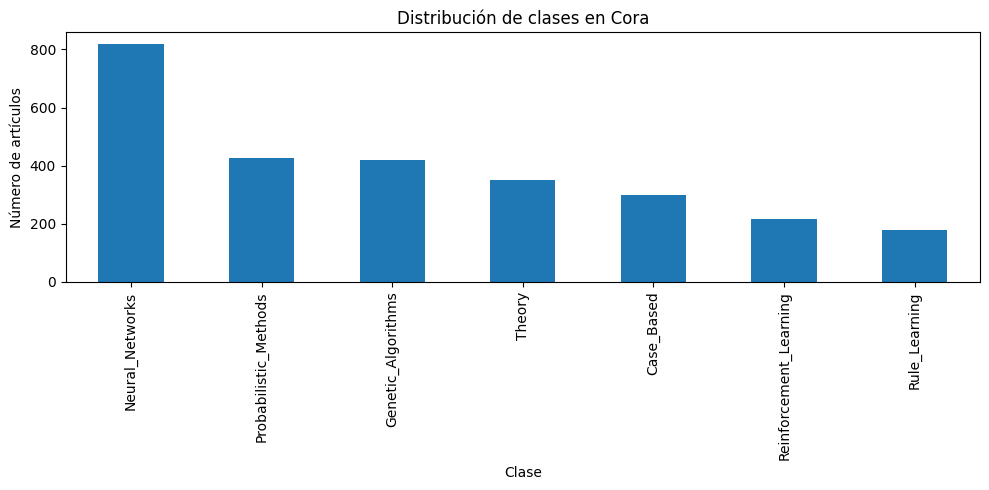

In [14]:
plt.figure(figsize=(10,5))
class_counts.plot(kind="bar")
plt.title("Distribución de clases en Cora")
plt.xlabel("Clase")
plt.ylabel("Número de artículos")
plt.tight_layout()
plt.show()

Vamos a comprobar posibles valores nulos

In [15]:
print("Nulos en contenido:")
print(contenido.isnull().sum().sum())

print("Nulos en citas:")
print(citas.isnull().sum().sum())

Nulos en contenido:
0
Nulos en citas:
0


En este caso no hay en ninguno de los dos.

In [17]:
print("Duplicados en contenido:")
print(contenido.duplicated().sum())

print("Duplicados en citas:")
print(citas.duplicated().sum())

Duplicados en contenido:
0
Duplicados en citas:
0


Tampoco hay duplicados.

In [18]:
articulos_citados = set(citas["articulo_citado_id"])
articulos_citantes = set(citas["articulo_citante_id"])

articulos_en_citas = articulos_citados.union(articulos_citantes)

print("Artículos presentes en relaciones:", len(articulos_en_citas))
print("Artículos totales:", contenido.shape[0])

Artículos presentes en relaciones: 2708
Artículos totales: 2708


El número de artículos distintos que aparecen en las citas es 2708, por tanto, no hay nodos aislados.

## Conclusiones

El dataset Cora contiene 2708 artículos científicos pertenecientes a 7 categorías distintas (Neural_Networks, Probabilistic_Methods, Genetic_Algorithms,Theory, Case_Based, Reinforcement_Learning y Rule_Learning).

Cada artículo está representado mediante 1433 atributos binarios que indican la presencia o ausencia de determinadas palabras.

Las relaciones de citación permiten modelar el conjunto como un grafo donde los nodos representan artículos y las aristas representan citas entre ellos. En total hay 5429 relaciones de citación.

Tras la exploración inicial no se han detectado valores perdidos ni problemas significativos de calidad de datos.

#### Algunas comprobaciones con palabras

In [19]:
palabras_activas = contenido.iloc[:, 1:-1].sum(axis=1)

print(palabras_activas.describe())

count    2708.000000
mean       18.174298
std         5.758010
min         1.000000
25%        17.000000
50%        20.000000
75%        22.000000
max        30.000000
dtype: float64


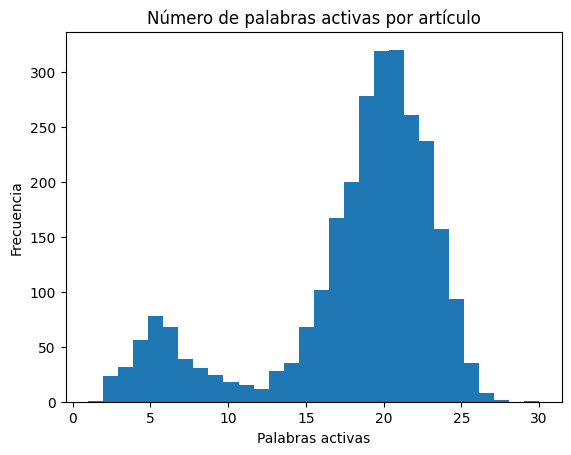

In [20]:
plt.hist(palabras_activas, bins=30)
plt.title("Número de palabras activas por artículo")
plt.xlabel("Palabras activas")
plt.ylabel("Frecuencia")
plt.show()